Immunogenicity prediction perfomed on one Minibinder and one VHH from Immunordic. Predictions was performed with netMHCpan EL, netMHC_II_pan EL and waltz. Only deafult settings, because of results from previous testing I have decided to only move forward with default.\
Here I compute the scores for them. Then load the anitbody and nanobody score tables (scores from different tools). The I make a plot for each tool where you can see how the minibinder and VHH place themself in comparison to the antibodies and nanobodies.

In [ ]:
# load libaries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

The settings used are default settings for all tools. It is netMHC EL and netMHC II EL. 

In [20]:
# load data
netMHC = pd.read_csv("tool_outputs/MB_netMHC_peplen9_30032026.csv")
netMHC_II = pd.read_csv("tool_outputs/MB_netMHC_II_peplen15_30032026.csv")
seq_table = pd.read_csv("tool_outputs/sequence_table_35eb2542.csv")
waltz = pd.read_csv("tool_outputs/MB_waltz.txt", sep="\t", header=None, names=["antibody", "waltz_score", "..."])
biophi = pd.read_excel("tool_outputs/MB_NrKab_CDRKab_Relaxed_30032026.xlsx")


In [21]:
# the netMHC tools do not have the antibody name in the output, only a sequence number
# Here the seq # will be mapped back to the original antibody name using the seqTable
netMHC = netMHC.merge(seq_table[['seq #', 'sequence name']], how='left')
netMHC_II = netMHC_II.merge(seq_table[['seq #', 'sequence name']], how='left')

# compute scores

In [22]:
# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC_percentile = (
    netMHC.assign(immunogenic=netMHC['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_percentile')
    )

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
class1pMHC_immunogen = (
    netMHC.assign(immunogenic=netMHC['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='class1pMHC_immunogen')
    )

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
basicPreProcessMCH1 = netMHC.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'basicPreProcessMCH1'})

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_percentile = (
    netMHC_II.assign(immunogenic=netMHC_II['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_percentile')
    )

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
CD4Episcore = (
    netMHC_II.assign(immunogenic=netMHC_II['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='CD4Episcore')
    )

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_clean = netMHC_II[netMHC_II['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_clean['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_pep15_cleavProb = netMHC_II_clean.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'mhcii-np cleavage probability score': 'MHCII_NP_pep15_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_clean = netMHC_II_clean[netMHC_II_clean['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_clean['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_pep15_cleavProbPercentile = netMHC_II_clean.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'MHCII_NP_pep15_cleavProbPercentile'})

# rename the column '...' to nr_aggs
waltz = waltz.rename(columns={'...': 'nr_aggs'})

# compute the total number of amio acids that are considerd immunogenetic
def sum_ranges(s):
    if pd.isna(s):
        return 0
    total = 0
    for part in s.split(';'):
        start, end = part.strip().split('-')
        total += int(end) - int(start) + 1 # beacuse the values are inclusive
    return total

waltz['nr_aggs'] = waltz['waltz_score'].apply(sum_ranges)

C:\Users\rebbe\AppData\Local\Temp\ipykernel_17348\1205559470.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netMHC_II_clean['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability score'])


In [23]:
# join all scores to one df

all_predictors = netMHC_percentile.merge(class1pMHC_immunogen, left_on='sequence name', right_on='sequence name', how='left').rename(columns={'sequence name': 'antibody'})
all_predictors = all_predictors.merge(basicPreProcessMCH1, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors = all_predictors.merge(netMHC_II_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors = all_predictors.merge(CD4Episcore, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors = all_predictors.merge(MHCII_NP_pep15_cleavProb, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors = all_predictors.merge(MHCII_NP_pep15_cleavProbPercentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors = all_predictors.merge(waltz[['antibody', 'nr_aggs']], left_on='antibody', right_on='antibody', how='left').rename(columns={'nr_aggs': 'waltz_nr_aggs'})
ll_predictors = all_predictors.merge(biophi[['Antibody', 'OASis Identity']], left_on='antibody', right_on='Antibody', how='left').drop(columns=['Antibody']).rename(columns={'OASis Identity': 'biophi'})


In [24]:
# export to csv
all_predictors.to_csv("Minibinders_tool_scores.csv")

In [25]:
# load Antibody and Nanobody scores
MB_all_predictors = all_predictors.copy()
NB_all_predictors = pd.read_csv("../3.feature_selection/Nanobodies/all_predictors_NB.csv")
AB_all_predictors = pd.read_csv("../3.feature_selection/Antibodies/ADA_combined_features.csv")

In [26]:
# Merge the data frames

# The minibinder df has less columns that the other two dfs. This is because the minibinders were only tested with default settings.
# The column names are also not the same, therefore manual mapping is needed

# manual mapping of AB df columns to the same names that are in the minibinder column names
AB_mapped = pd.DataFrame({
    'antibody': AB_all_predictors['antibody'],
    'ADA_percantage': AB_all_predictors['ADA_percentage'],
    'netMHC_percentile': AB_all_predictors['netMHC1_pep9_percentile'],
    'class1pMHC_immunogen': AB_all_predictors['class1pMHC_immunogen_pep9'],
    'basicPreProcessMCH1': AB_all_predictors['basicPreProcessMCH1_pep9'],
    'netMHC_II_percentile': AB_all_predictors['netMHC_II_pep15_percentile'],
    'CD4Episcore': AB_all_predictors['CD4Episcore_pep15'],
    'MHCII_NP_pep15_cleavProb': AB_all_predictors['MHCII_NP_pep15_cleavProb'],
    'MHCII_NP_pep15_cleavProbPercentile': AB_all_predictors['MHCII_NP_pep15_cleavProbPercentile'],
    'waltz_nr_aggs': AB_all_predictors['waltz_nr_aggs']
})

# Add the antibodies and minibinders to one df
combined = pd.concat([MB_all_predictors, AB_mapped], ignore_index=True)


# manual mapping of the nanobodies df to the minibinder df
NB_mapped = pd.DataFrame({
    'antibody': NB_all_predictors['antibody'],
    'ADA_percantage': NB_all_predictors['ADA_percentage'],
    'netMHC_percentile': NB_all_predictors['netMHC1_pep9_percentile'],
    'class1pMHC_immunogen': NB_all_predictors['class1pMHC_immunogen_pep9'],
    'basicPreProcessMCH1': NB_all_predictors['basicPreProcessMCH1_pep9'],
    'netMHC_II_percentile': NB_all_predictors['netMHC_II_pep15_percentile'],
    'CD4Episcore': NB_all_predictors['CD4Episcore_pep15'],
    'MHCII_NP_pep15_cleavProb': NB_all_predictors['MHCII_NP_pep15_cleavProb'],
    'MHCII_NP_pep15_cleavProbPercentile': NB_all_predictors['MHCII_NP_pep15_cleavProbPercentile'],
    'waltz_nr_aggs': NB_all_predictors['waltz_nr_aggs']
})

# Add the nanobodies and combines dfs together
combined = pd.concat([combined, NB_mapped], ignore_index=True)

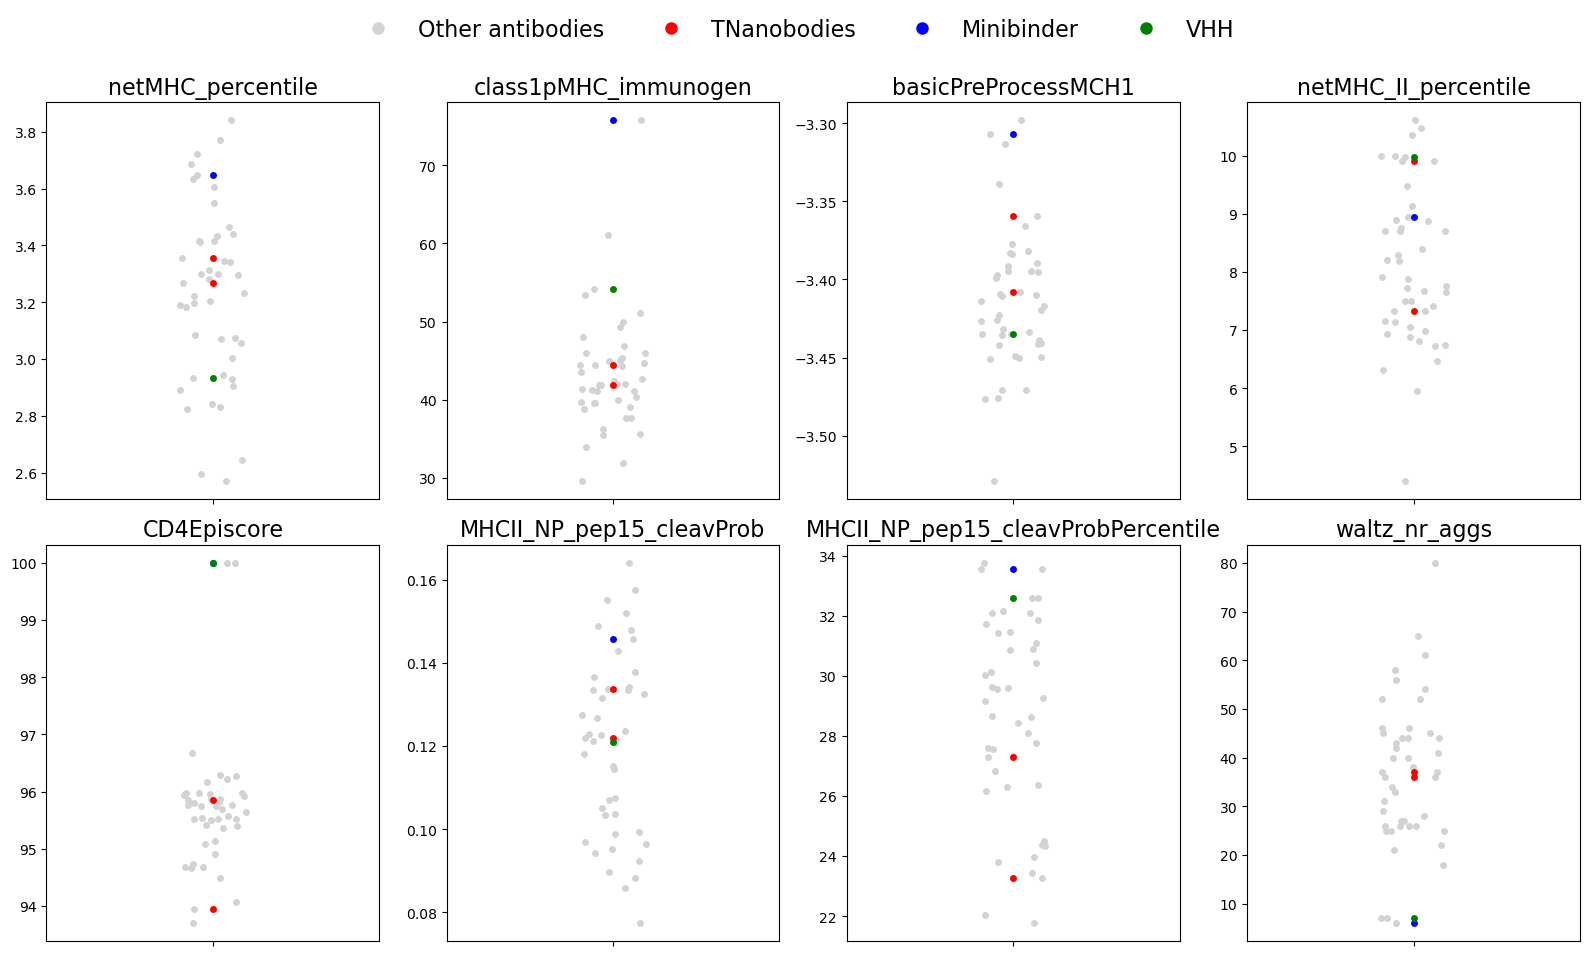

In [36]:


fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for j, i in enumerate(range(1, 9)):
    ax = axes[j]
    col_name = combined.columns[i]

    sns.stripplot(
        y=combined.iloc[:, i],
        color='lightgray',
        ax=ax
    )

    sns.stripplot(
        y=combined.loc[combined['antibody'].isin(['Tarperprumig_ALXN1820']), col_name],
        color='red', ax=ax
    )

    sns.stripplot(
        y=combined.loc[combined['antibody'].isin(['ALEMTUZUMAB']), col_name],
        color='red', ax=ax
    )

    sns.stripplot(
        y=combined.loc[combined['antibody'].isin(['Minibinder']), col_name],
        color='blue', ax=ax
    )

    sns.stripplot(
        y=combined.loc[combined['antibody'].isin(['VHH']), col_name],
        color='green', ax=ax
    )

    ax.set_title(col_name, fontsize=16)
    ax.set_ylabel('')

# Custom legend (bigger markers + text)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Other antibodies',
           markerfacecolor='lightgray', markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='TNanobodies',
           markerfacecolor='red', markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='Minibinder',
           markerfacecolor='blue', markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='VHH',
           markerfacecolor='green', markersize=10)
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.07),  # pushes it slightly above plots but controlled
    ncol=4,
    fontsize=16,
    frameon=False
)

# Reserve space for legend and titles
plt.subplots_adjust(top=0.88)

plt.tight_layout()
plt.show()

In [28]:
combined

,antibody,netMHC_percentile,class1pMHC_immunogen,basicPreProcessMCH1,netMHC_II_percentile,CD4Episcore,MHCII_NP_pep15_cleavProb,MHCII_NP_pep15_cleavProbPercentile,waltz_nr_aggs,ADA_percantage
0,Minibinder,3.647587,75.757576,-3.307013,8.950617,100.000000,0.145695,33.539091,6,NaN
1,VHH,2.932099,54.166667,-3.434640,9.983897,100.000000,0.120871,32.587273,7,NaN
2,BEZLOTOXUMAB,3.433113,38.812785,-3.419684,7.149009,96.283128,0.122660,28.419048,36,0.00
3,VISILIZUMAB,3.414883,33.944954,-3.422947,8.871662,95.770937,0.115206,27.552143,37,0.00
4,OMALIZUMAB,3.191138,39.732143,-3.451108,8.754209,95.977432,0.133465,23.795814,28,0.06
5,EVOLOCUMAB,2.572016,29.629630,-3.528689,6.878307,95.519226,0.127434,31.844878,18,0.27
6,SECUKINUMAB,3.312123,51.101322,-3.339047,8.888889,95.503731,0.136671,26.353721,56,0.35
7,DENOSUMAB,3.003003,45.945946,-3.440766,7.912458,95.764075,0.132494,28.100476,34,0.68
8,IBALIZUMAB,3.441495,42.035398,-3.398900,10.353535,95.968589,0.157467,26.302326,58,0.68
9,OCRELIZUMAB,3.299663,40.000000,-3.383427,8.699397,95.697740,0.098803,31.407381,41,0.92
